# Task 2: Recommender Systems without Surprise (Python 3.12 Compatible)

We implement:
- Probabilistic Matrix Factorization (PMF) via simple matrix factorization with SGD
- User-based Collaborative Filtering (UserCF)
- Item-based Collaborative Filtering (ItemCF)

We evaluate:
- MAE and RMSE under 5-fold cross-validation
- The effect of different similarity metrics (cosine, MSD, Pearson)
- The effect of the number of neighbors (K)


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
import matplotlib.pyplot as plt

pd.set_option("display.precision", 4)

# Load ratings_small.csv (put it in the same folder as this notebook)
ratings = pd.read_csv("ratings_small.csv")  # columns: userId, movieId, rating, timestamp
ratings = ratings[['userId', 'movieId', 'rating']]  # we only need these columns
ratings.head(), ratings.shape


(   userId  movieId  rating
 0       1       31     2.5
 1       1     1029     3.0
 2       1     1061     3.0
 3       1     1129     2.0
 4       1     1172     4.0,
 (100004, 3))

In [2]:
def compute_mae_rmse(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

def create_id_mappings(df):
    """Map raw userId/movieId to contiguous indices 0..n-1."""
    unique_users = df['userId'].unique()
    unique_items = df['movieId'].unique()

    user_id_to_idx = {u: i for i, u in enumerate(unique_users)}
    item_id_to_idx = {m: i for i, m in enumerate(unique_items)}

    idx_to_user_id = {i: u for u, i in user_id_to_idx.items()}
    idx_to_item_id = {i: m for m, i in item_id_to_idx.items()}

    return user_id_to_idx, item_id_to_idx, idx_to_user_id, idx_to_item_id


In [3]:
class PMFModel:
    """
    Simple matrix factorization for explicit ratings using SGD.
    r_ui ≈ p_u · q_i
    """

    def __init__(self, n_factors=20, n_epochs=15, lr=0.01, reg=0.02, random_state=42):
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg
        self.random_state = random_state

        self.user_factors = None  # P
        self.item_factors = None  # Q
        self.global_mean = None
        self.user_id_to_idx = None
        self.item_id_to_idx = None

    def fit(self, train_df):
        # mappings
        self.user_id_to_idx, self.item_id_to_idx, _, _ = create_id_mappings(train_df)

        n_users = len(self.user_id_to_idx)
        n_items = len(self.item_id_to_idx)

        # latent matrices
        rng = np.random.default_rng(self.random_state)
        self.user_factors = 0.1 * rng.standard_normal((n_users, self.n_factors))
        self.item_factors = 0.1 * rng.standard_normal((n_items, self.n_factors))

        # prepare training triples (u_idx, i_idx, rating)
        train_records = []
        for _, row in train_df.iterrows():
            u = self.user_id_to_idx[row['userId']]
            i = self.item_id_to_idx[row['movieId']]
            r = row['rating']
            train_records.append((u, i, r))

        self.global_mean = train_df['rating'].mean()

        # SGD
        for epoch in range(self.n_epochs):
            rng.shuffle(train_records)
            for u, i, r in train_records:
                pred = np.dot(self.user_factors[u], self.item_factors[i])
                err = r - pred

                # gradient updates
                pu = self.user_factors[u]
                qi = self.item_factors[i]

                self.user_factors[u] += self.lr * (err * qi - self.reg * pu)
                self.item_factors[i] += self.lr * (err * pu - self.reg * qi)

        return self

    def predict(self, user_id, item_id):
        # unseen user/item -> fallback to global mean
        if (user_id not in self.user_id_to_idx) or (item_id not in self.item_id_to_idx):
            return float(self.global_mean)

        u = self.user_id_to_idx[user_id]
        i = self.item_id_to_idx[item_id]
        pred = np.dot(self.user_factors[u], self.item_factors[i])
        # clamp to [1, 5]
        return float(np.clip(pred, 1.0, 5.0))


In [4]:
from abc import ABC, abstractmethod

def build_rating_matrix(train_df):
    user_id_to_idx, item_id_to_idx, idx_to_user_id, idx_to_item_id = create_id_mappings(train_df)
    n_users = len(user_id_to_idx)
    n_items = len(item_id_to_idx)

    R = np.zeros((n_users, n_items), dtype=np.float32)
    for _, row in train_df.iterrows():
        u = user_id_to_idx[row['userId']]
        i = item_id_to_idx[row['movieId']]
        R[u, i] = row['rating']

    return R, user_id_to_idx, item_id_to_idx, idx_to_user_id, idx_to_item_id

def compute_similarity_matrix(matrix, mode="user", metric="cosine"):
    """
    matrix: R (users x items) if mode='user'; R.T for items-mode.
    metric: 'cosine', 'msd', 'pearson'
    Missing entries are treated as 0 (simple approximation).
    """
    X = matrix.copy()

    if metric == "cosine":
        sim = cosine_similarity(X)
    elif metric == "msd":
        # mean squared difference -> similarity = 1 / (1 + MSD)
        dists = pairwise_distances(X, metric="euclidean")
        msd = (dists ** 2) / X.shape[1]
        sim = 1.0 / (1.0 + msd)
    elif metric == "pearson":
        # center by (non-zero) mean for each row
        X_centered = X.copy()
        row_means = np.where(
            (X != 0).sum(axis=1) > 0,
            X.sum(axis=1) / np.maximum((X != 0).sum(axis=1), 1),
            0
        )
        X_centered = X_centered - row_means[:, None]
        sim = np.corrcoef(X_centered)
        # NaN may appear if variance=0
        sim = np.nan_to_num(sim, nan=0.0)
    else:
        raise ValueError("Unknown metric")

    # zero out self-similarity
    np.fill_diagonal(sim, 0.0)
    return sim

class BaseCF(ABC):
    def __init__(self, k=20, similarity="cosine", user_based=True):
        self.k = k
        self.similarity = similarity
        self.user_based = user_based

        self.R = None
        self.user_id_to_idx = None
        self.item_id_to_idx = None
        self.sim_matrix = None
        self.global_mean = None

    def fit(self, train_df):
        R, user_id_to_idx, item_id_to_idx, _, _ = build_rating_matrix(train_df)
        self.R = R
        self.user_id_to_idx = user_id_to_idx
        self.item_id_to_idx = item_id_to_idx
        self.global_mean = train_df['rating'].mean()

        if self.user_based:
            self.sim_matrix = compute_similarity_matrix(R, mode="user", metric=self.similarity)
        else:
            self.sim_matrix = compute_similarity_matrix(R.T, mode="item", metric=self.similarity)

        return self

    @abstractmethod
    def predict(self, user_id, item_id):
        pass


In [5]:
class UserCFModel(BaseCF):
    """
    User-based CF with k nearest neighbors and given similarity metric.
    """

    def __init__(self, k=20, similarity="cosine"):
        super().__init__(k=k, similarity=similarity, user_based=True)

    def predict(self, user_id, item_id):
        if (user_id not in self.user_id_to_idx) or (item_id not in self.item_id_to_idx):
            return float(self.global_mean)

        u = self.user_id_to_idx[user_id]
        i = self.item_id_to_idx[item_id]

        # users who rated item i
        item_ratings = self.R[:, i]
        rated_idx = np.where(item_ratings > 0)[0]
        if len(rated_idx) == 0:
            return float(self.global_mean)

        # similarities from target user u to others
        sims = self.sim_matrix[u, rated_idx]

        # select top-k neighbors
        if len(rated_idx) > self.k:
            top_k_idx = np.argsort(sims)[-self.k:]
            rated_idx = rated_idx[top_k_idx]
            sims = sims[top_k_idx]

        if np.all(sims == 0):
            return float(self.global_mean)

        ratings = self.R[rated_idx, i]
        pred = np.dot(sims, ratings) / np.sum(np.abs(sims))
        return float(np.clip(pred, 1.0, 5.0))


class ItemCFModel(BaseCF):
    """
    Item-based CF with k nearest neighbors and given similarity metric.
    """

    def __init__(self, k=20, similarity="cosine"):
        super().__init__(k=k, similarity=similarity, user_based=False)

    def predict(self, user_id, item_id):
        if (user_id not in self.user_id_to_idx) or (item_id not in self.item_id_to_idx):
            return float(self.global_mean)

        u = self.user_id_to_idx[user_id]
        i = self.item_id_to_idx[item_id]

        # items rated by user u
        user_ratings = self.R[u, :]
        rated_items = np.where(user_ratings > 0)[0]
        if len(rated_items) == 0:
            return float(self.global_mean)

        sims = self.sim_matrix[i, rated_items]

        if len(rated_items) > self.k:
            top_k_idx = np.argsort(sims)[-self.k:]
            rated_items = rated_items[top_k_idx]
            sims = sims[top_k_idx]

        if np.all(sims == 0):
            return float(self.global_mean)

        ratings = self.R[u, rated_items]
        pred = np.dot(sims, ratings) / np.sum(np.abs(sims))
        return float(np.clip(pred, 1.0, 5.0))


In [6]:
def cross_validate_model(model_class, model_kwargs, ratings_df, n_splits=5, verbose=True):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    maes = []
    rmses = []

    fold = 1
    for train_idx, test_idx in kf.split(ratings_df):
        train_df = ratings_df.iloc[train_idx]
        test_df = ratings_df.iloc[test_idx]

        model = model_class(**model_kwargs)
        model.fit(train_df)

        y_true = []
        y_pred = []

        for _, row in test_df.iterrows():
            u = row['userId']
            i = row['movieId']
            r = row['rating']
            p = model.predict(u, i)
            y_true.append(r)
            y_pred.append(p)

        mae, rmse = compute_mae_rmse(np.array(y_true), np.array(y_pred))
        maes.append(mae)
        rmses.append(rmse)

        if verbose:
            print(f"Fold {fold}: MAE={mae:.4f}, RMSE={rmse:.4f}")
        fold += 1

    return np.mean(maes), np.mean(rmses)


In [7]:
results_cd = []

# 1. PMF
mae_pmf, rmse_pmf = cross_validate_model(
    PMFModel,
    {"n_factors": 20, "n_epochs": 10, "lr": 0.01, "reg": 0.05},
    ratings,
    verbose=True
)
results_cd.append(["PMF", mae_pmf, rmse_pmf])

# 2. User-based CF (cosine, k=20)
mae_ubcf, rmse_ubcf = cross_validate_model(
    UserCFModel,
    {"k": 20, "similarity": "cosine"},
    ratings,
    verbose=True
)
results_cd.append(["UserCF (cosine, k=20)", mae_ubcf, rmse_ubcf])

# 3. Item-based CF (cosine, k=20)
mae_ibcf, rmse_ibcf = cross_validate_model(
    ItemCFModel,
    {"k": 20, "similarity": "cosine"},
    ratings,
    verbose=True
)
results_cd.append(["ItemCF (cosine, k=20)", mae_ibcf, rmse_ibcf])

df_cd = pd.DataFrame(results_cd, columns=["Model", "MAE", "RMSE"])
df_cd


Fold 1: MAE=0.7510, RMSE=0.9777
Fold 2: MAE=0.7464, RMSE=0.9734
Fold 3: MAE=0.7501, RMSE=0.9751
Fold 4: MAE=0.7477, RMSE=0.9772
Fold 5: MAE=0.7528, RMSE=0.9789
Fold 1: MAE=0.7699, RMSE=0.9902
Fold 2: MAE=0.7644, RMSE=0.9831
Fold 3: MAE=0.7716, RMSE=0.9919
Fold 4: MAE=0.7646, RMSE=0.9898
Fold 5: MAE=0.7677, RMSE=0.9878
Fold 1: MAE=0.6829, RMSE=0.8984
Fold 2: MAE=0.6831, RMSE=0.8975
Fold 3: MAE=0.6866, RMSE=0.9023
Fold 4: MAE=0.6821, RMSE=0.8970
Fold 5: MAE=0.6959, RMSE=0.9124


,Model,MAE,RMSE
0,PMF,0.7496,0.9764
1,"UserCF (cosine, k=20)",0.7676,0.9885
2,"ItemCF (cosine, k=20)",0.6862,0.9015


In [8]:
similarities = ["cosine", "msd", "pearson"]

rmse_user_sim = []
rmse_item_sim = []

for sim in similarities:
    print(f"\nUserCF with similarity = {sim}")
    _, rmse_u = cross_validate_model(
        UserCFModel,
        {"k": 20, "similarity": sim},
        ratings,
        verbose=False
    )
    rmse_user_sim.append(rmse_u)
    print(f"  RMSE = {rmse_u:.4f}")

    print(f"ItemCF with similarity = {sim}")
    _, rmse_i = cross_validate_model(
        ItemCFModel,
        {"k": 20, "similarity": sim},
        ratings,
        verbose=False
    )
    rmse_item_sim.append(rmse_i)
    print(f"  RMSE = {rmse_i:.4f}")

rmse_user_sim, rmse_item_sim



UserCF with similarity = cosine
  RMSE = 0.9885
ItemCF with similarity = cosine
  RMSE = 0.9015

UserCF with similarity = msd
  RMSE = 1.0021
ItemCF with similarity = msd
  RMSE = 1.1175

UserCF with similarity = pearson
  RMSE = 0.9896
ItemCF with similarity = pearson
  RMSE = 0.8967


([np.float64(0.9885487064096191),
  np.float64(1.00214557237917),
  np.float64(0.9895601597958308)],
 [np.float64(0.901514884458766),
  np.float64(1.1175220296715809),
  np.float64(0.8967246480854026)])

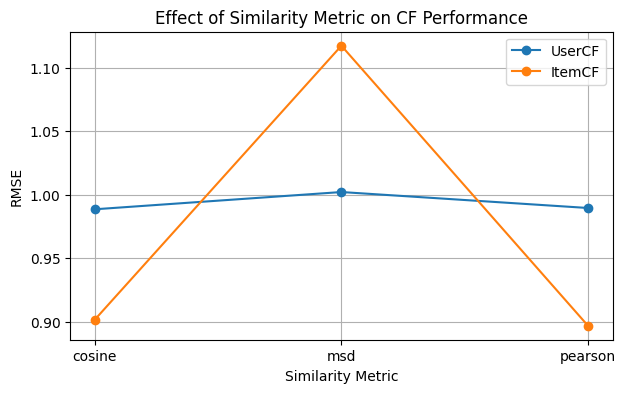

In [9]:
plt.figure(figsize=(7,4))
plt.plot(similarities, rmse_user_sim, marker='o', label="UserCF")
plt.plot(similarities, rmse_item_sim, marker='o', label="ItemCF")
plt.xlabel("Similarity Metric")
plt.ylabel("RMSE")
plt.title("Effect of Similarity Metric on CF Performance")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
K_values = [5, 10, 20, 40, 60]

rmse_user_k = []
rmse_item_k = []

for k in K_values:
    print(f"\nUserCF, k={k}")
    _, rmse_u = cross_validate_model(
        UserCFModel,
        {"k": k, "similarity": "cosine"},
        ratings,
        verbose=False
    )
    rmse_user_k.append(rmse_u)
    print(f"  RMSE = {rmse_u:.4f}")

    print(f"ItemCF, k={k}")
    _, rmse_i = cross_validate_model(
        ItemCFModel,
        {"k": k, "similarity": "cosine"},
        ratings,
        verbose=False
    )
    rmse_item_k.append(rmse_i)
    print(f"  RMSE = {rmse_i:.4f}")

rmse_user_k, rmse_item_k



UserCF, k=5
  RMSE = 1.0188
ItemCF, k=5
  RMSE = 0.9334

UserCF, k=10
  RMSE = 0.9959
ItemCF, k=10
  RMSE = 0.9068

UserCF, k=20
  RMSE = 0.9885
ItemCF, k=20
  RMSE = 0.9015

UserCF, k=40
  RMSE = 0.9878
ItemCF, k=40
  RMSE = 0.9071

UserCF, k=60
  RMSE = 0.9881
ItemCF, k=60
  RMSE = 0.9131


([np.float64(1.018830303357819),
  np.float64(0.9958540879855604),
  np.float64(0.9885487064096191),
  np.float64(0.9877641400912147),
  np.float64(0.9881361097780947)],
 [np.float64(0.9333979880942023),
  np.float64(0.9067842101507468),
  np.float64(0.901514884458766),
  np.float64(0.9071023802964371),
  np.float64(0.9131139932698586)])

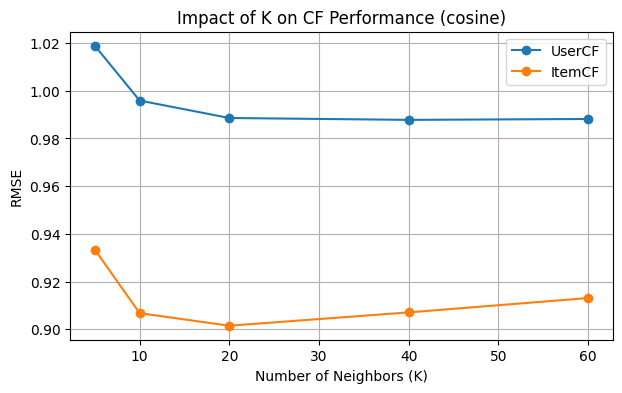

In [11]:
plt.figure(figsize=(7,4))
plt.plot(K_values, rmse_user_k, marker='o', label="UserCF")
plt.plot(K_values, rmse_item_k, marker='o', label="ItemCF")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.title("Impact of K on CF Performance (cosine)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
best_user_k = K_values[int(np.argmin(rmse_user_k))]
best_item_k = K_values[int(np.argmin(rmse_item_k))]

print("Best K for UserCF (by RMSE):", best_user_k)
print("Best K for ItemCF (by RMSE):", best_item_k)


Best K for UserCF (by RMSE): 40
Best K for ItemCF (by RMSE): 20
